In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("superstore_eda_v1-1724655032 (1).csv")

In [4]:
#Basic information and Duplicate Values - 

print(df.head())
print(df.info())
print(df.isnull().sum())

   Row ID        Order ID Order Date Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   08/11/16  11/11/16    Second Class    CG-12520   
1       2  CA-2016-152156   08/11/16  11/11/16    Second Class    CG-12520   
2       3  CA-2016-138688   12/06/16  16/06/16    Second Class    DV-13045   
3       4  US-2015-108966   11/10/15  18/10/15  Standard Class    SO-20335   
4       5  US-2015-108966   11/10/15  18/10/15  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10001798

In [5]:
#Removing  Duplicates Values - 

df = df.drop_duplicates()

In [6]:
#Date Handling - 

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

C:\Users\Hp\AppData\Local\Temp\ipykernel_18780\989336505.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
C:\Users\Hp\AppData\Local\Temp\ipykernel_18780\989336505.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [7]:
#Fill Ship Mode - 

df.loc[df['Days to Ship']==0, 'Ship Mode'] = "Same Day"
df.loc[df['Days to Ship']==7, 'Ship Mode'] = "Standard Class"

In [8]:
#Fill Quantity -

df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [9]:
#Data Cleaning -

df.drop('Customer Name', axis=1, inplace=True)
df['Customer Name Masked'] = df['Customer ID'].str[:2]

In [10]:
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

In [11]:
#Data Types -

df['Sales Price'] = pd.to_numeric(df['Sales Price'], errors='coerce')
df['Quantity'] = df['Quantity'].astype(int)

In [12]:
#Feature Engineering -

df['Total Sales'] = df['Sales Price'] * df['Quantity']
df['Total Profit'] = df['Profit'] * df['Quantity']

In [13]:
#Reomving the Outliers (3*IQR) - 

Q1 = df['Sales Price'].quantile(0.25)
Q3 = df['Sales Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Sales Price'] >= Q1-3*IQR) & (df['Sales Price'] <= Q3+3*IQR)]

In [14]:
#Quintiles -

df['Sales Quintile'] = pd.qcut(df['Total Sales'], 5, labels=False)
df['Profit Quintile'] = pd.qcut(df['Total Profit'], 5, labels=False)

In [15]:
df.to_csv("cleaned_data.csv", index=False)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

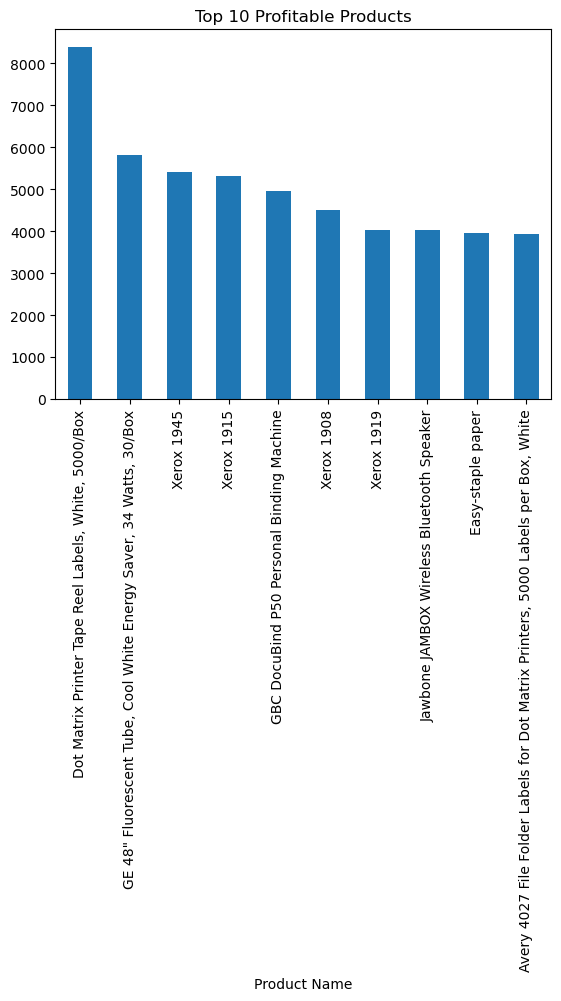

In [24]:
#Visualizations -

#Top 10 profitable products
#Loss-making products
#Sales vs Profit scatter
#Monthly trends

#Top 10 Profitable Products - 

top_profit = df.groupby('Product Name')['Total Profit'].sum().nlargest(10)
top_profit.plot(kind='bar', title='Top 10 Profitable Products')
plt.show()

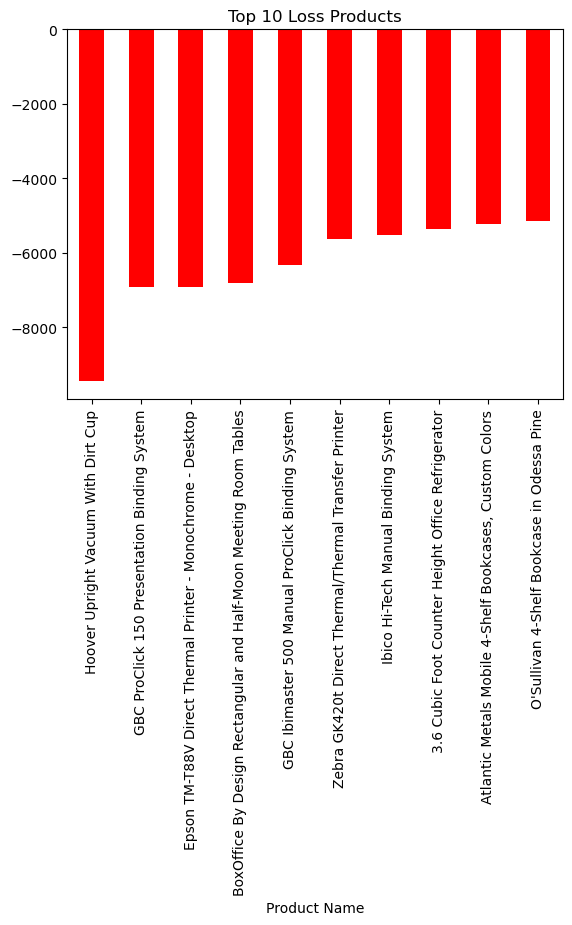

In [19]:
#Top 10 Loss Making Products -

loss = df.groupby('Product Name')['Total Profit'].sum().nsmallest(10)
loss.plot(kind='bar', title='Top 10 Loss Products', color='red')
plt.show()

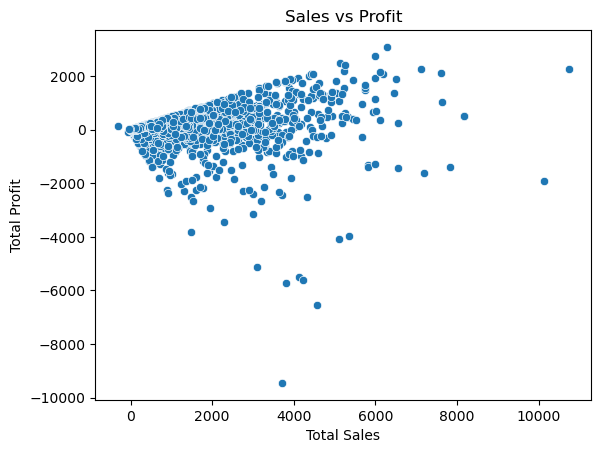

In [20]:
#Sales vs Profit -

sns.scatterplot(x='Total Sales', y='Total Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

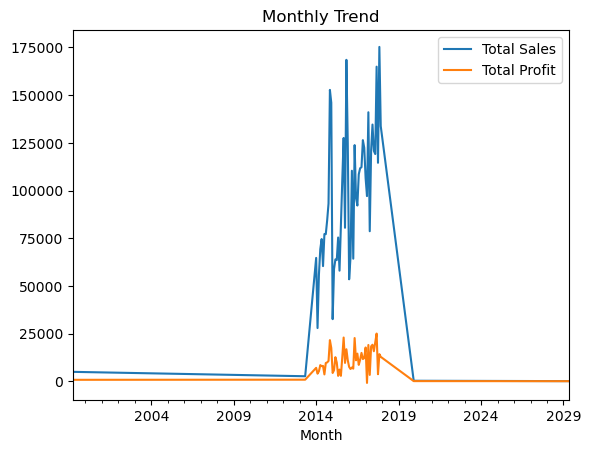

In [21]:
#Monthly Trend -

df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')[['Total Sales','Total Profit']].sum()
monthly.plot(title='Monthly Trend')
plt.show()

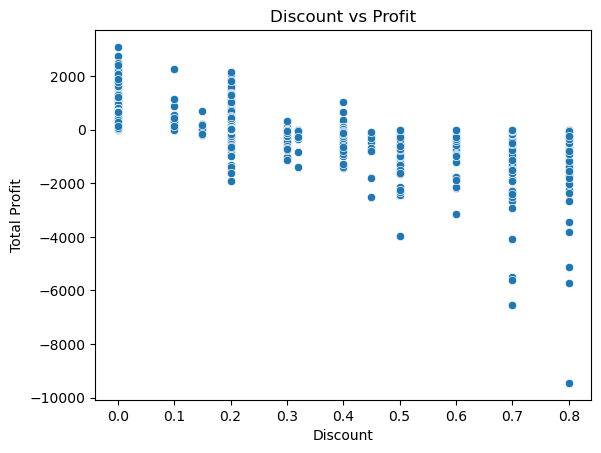

In [22]:
#Discount vs Profit -

sns.scatterplot(x='Discount', y='Total Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

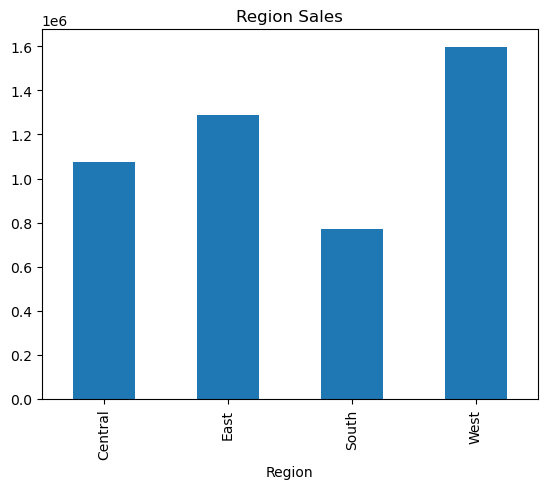

In [23]:
#Region-wise Sales -

region = df.groupby('Region')['Total Sales'].sum()
region.plot(kind='bar', title='Region Sales')
plt.show()

## Key Insights :- 

1. High sales ≠ high profit → some products generate losses  
2. Heavy discounts reduce profitability  
3. Few products contribute most profit (Pareto effect)  
4. Certain regions dominate sales  
5. Seasonal trends exist (peak months)  
6. Faster shipping doesn’t always increase profit  
7. Some categories are low-margin  